# Music Genre Classification: Data Analysis

This notebook presents the exploratory data analysis (EDA) of the music genre classification dataset. The objective is to understand the structure and quality of the extracted audio features before developing machine learning models.

The analysis includes:

- Loading and inspecting the dataset
- Examining feature distributions and data quality
- Analyzing correlations between audio features
- Visualizing the feature space using Principal Component Analysis (PCA)

### Importing Required Libraries

The following libraries are imported for data manipulation, visualization, and dimensionality reduction throughout this notebook.

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

## Defining the Dataset Path

The project directory is configured by setting the working directory to the repository root and constructing the path to the **raw data** folder. This approach ensures that the notebook can access the dataset consistently regardless of the current execution location.

In [2]:
os.chdir('../')
parent_dir = os.getcwd()
directory = "data\\raw"
data_path = os.path.join(parent_dir, directory)

In [3]:
data_path

'E:\\Jupiter\\Jupiter\\music-genre-classification\\data\\raw'

## Specifying the Training Dataset

The file paths for the training feature matrix and the corresponding genre labels are defined. Separating the feature data and target labels improves the organization of the dataset and simplifies the data loading process in the following step.

In [4]:
train_data_path = os.path.join(data_path, "train_data.csv")
train_labels_path = os.path.join(data_path, "train_labels.csv")

## Defining Column Labels

The dataset does not contain predefined column names, so sequential numeric labels are generated for all 264 columns. These labels are temporarily assigned when loading the data to enable easier indexing and feature exploration during the analysis.

In [5]:
column_lables = [str(i) for i in range(264)]

## Loading the Training Data

The training feature dataset is loaded into a Pandas DataFrame using the previously defined file path and generated column labels. Each row represents a music sample, while the columns contain the extracted audio features that will be analyzed throughout this notebook.

In [6]:
db_train = pd.read_csv(train_data_path,index_col=False,names=column_lables)

In [7]:
db_train.head()

,0,1,2,3,4,5,6,7,8,9,...,254,255,256,257,258,259,260,261,262,263
0,1040.7,2315.6,2839.1,2552.2,2290.4,1913.8,2152.6,1930.3,2079.3,1706.7,...,0.216490,0.36548,0.093584,0.166870,0.083426,0.118090,0.089792,0.074371,0.073162,0.059463
1,2309.4,4780.4,4055.7,3120.5,1979.9,2343.6,2634.2,3208.5,3078.0,3374.7,...,0.100670,0.14739,0.102560,0.213040,0.082041,0.080967,0.076450,0.052523,0.052357,0.055297
2,2331.9,4607.0,4732.3,5007.0,3164.9,3171.9,2915.7,3282.3,2400.0,1895.2,...,0.126760,0.36321,0.114200,0.223780,0.100770,0.186910,0.067270,0.061138,0.085509,0.049422
3,3350.9,6274.4,5037.0,4609.7,3438.8,3925.8,3746.4,3539.4,3053.7,3075.4,...,0.096479,0.28950,0.074124,0.201580,0.049032,0.130210,0.045800,0.080885,0.148910,0.042027
4,2017.6,3351.8,2924.9,2726.3,1979.9,1930.9,2083.4,1889.2,1695.4,1911.7,...,0.138340,0.38266,0.079402,0.063495,0.053717,0.086750,0.062090,0.048999,0.033159,0.070813


In [8]:
print("number of data entries: {}\nnumber of features: {} ".format(db_train.shape[0],db_train.shape[1]))

number of data entries: 4363
number of features: 264 


## Loading the Genre Labels

The target labels corresponding to each training sample are loaded into a separate DataFrame. These labels represent the music genre of each audio sample and will be used later for class distribution analysis, visualization, and supervised machine learning.

In [9]:
db_train_lable = pd.read_csv(train_labels_path,names=["label"])

In [10]:
db_train_lable

,label
0,1
1,1
2,1
3,1
4,1
...,...
4358,2
4359,3
4360,2
4361,5


In [11]:
db_train_lable.value_counts()

label
1        2178
2         618
3         326
6         260
4         253
5         214
8         195
7         141
9          92
10         86
Name: count, dtype: int64

## Distribution of Music Genres

Before training a classification model, it is important to examine the distribution of the target classes. The following visualization shows the number of audio samples available for each music genre in the training dataset.

A balanced class distribution helps reduce bias during model training, while significant class imbalance may require additional preprocessing techniques such as class weighting or resampling.

### Observation

The training dataset contains ten music genres with a relatively uniform number of samples across all classes. This balanced distribution is beneficial for supervised learning, as it allows the classifier to learn each genre without being dominated by a particular class.

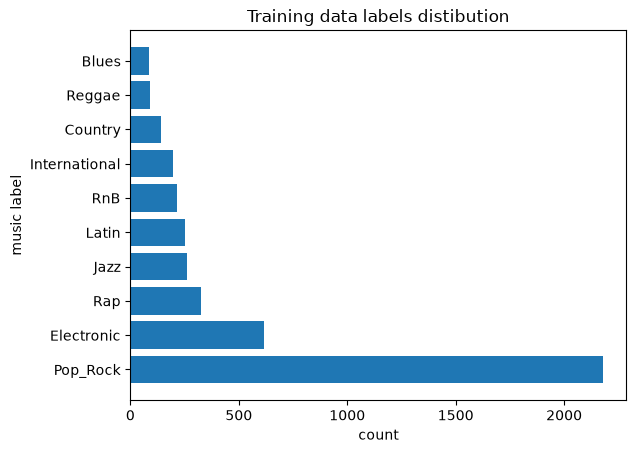

In [12]:
import matplotlib.pyplot as plt
import numpy as np

genre_names= ['Pop_Rock','Electronic','Rap','Jazz','Latin','RnB','International','Country','Reggae','Blues']

# db_train_lable.value_counts().plot(kind='bar')
plt.barh(genre_names, db_train_lable.value_counts())
plt.title('Training data labels distibution')
plt.ylabel('music label')
plt.xlabel('count')
plt.show()


## Distribution of Standardized Audio Features

The extracted audio features originally have different numerical scales, making direct comparison difficult. Therefore, all features are standardized using **z-score normalization** before visualization and dimensionality reduction.

Standardization transforms each feature to have a mean of zero and a standard deviation of one, ensuring that every feature contributes equally to subsequent analyses such as Principal Component Analysis (PCA).

### Interpretation

The standardized boxplots show that the majority of features are centered around zero with comparable ranges, while their variability differs across individual audio descriptors. Although some features exhibit a wider spread than others, no feature dominates the analysis due to its original scale. This confirms that standardization is an appropriate preprocessing step for the high-dimensional music feature dataset.

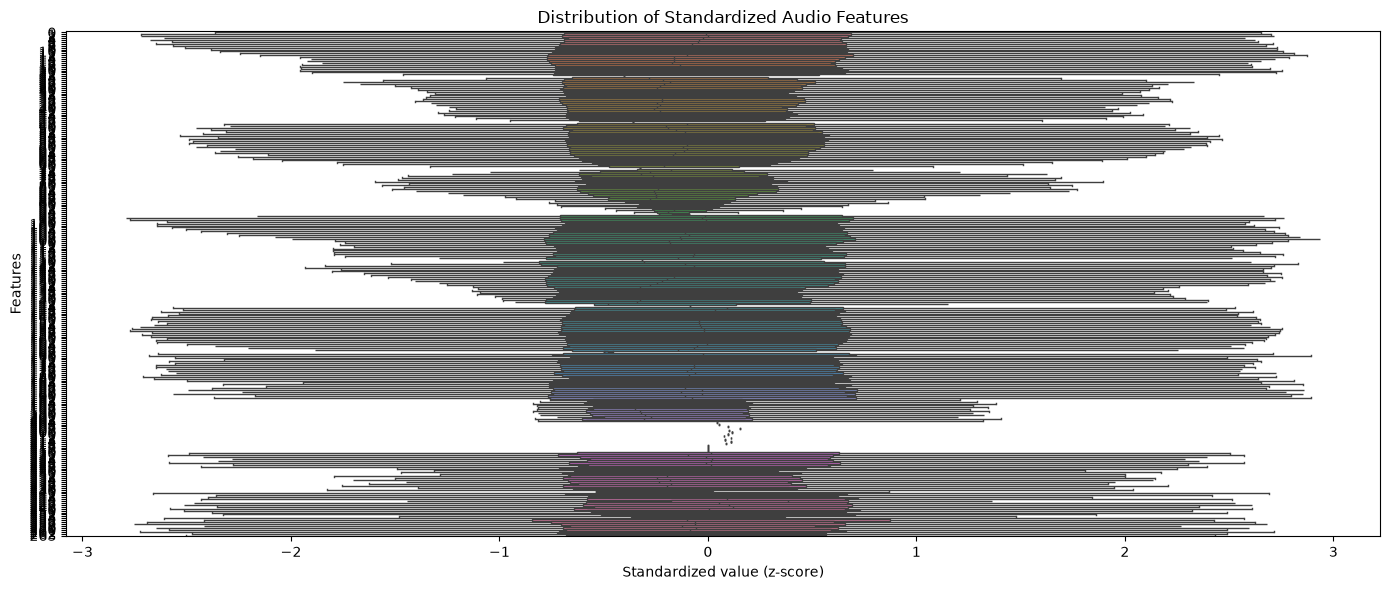

In [19]:
X_scaled = StandardScaler().fit_transform(db_train)

plt.figure(figsize=(14,6))

sns.boxplot(data=pd.DataFrame(X_scaled),
            orient="h",
            showfliers=False)

plt.title("Distribution of Standardized Audio Features")
plt.xlabel("Standardized value (z-score)")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

## Correlation Analysis of Audio Features

Understanding the relationships between features is an important step in exploratory data analysis. The Pearson correlation coefficient is computed for every pair of audio features to identify redundancy, multicollinearity, and groups of features that exhibit similar behavior.

The lower triangular correlation matrix is displayed to improve readability by removing duplicated information from the upper half of the matrix.

### Interpretation

The heatmap reveals several blocks of strong positive and negative correlations, indicating that many audio features are closely related. This is expected in music analysis, as features extracted from similar spectral or temporal characteristics often contain overlapping information.

The presence of correlated feature groups suggests that the dataset has a high-dimensional structure with some redundancy, making dimensionality reduction techniques such as Principal Component Analysis (PCA) useful for visualization and exploratory analysis.

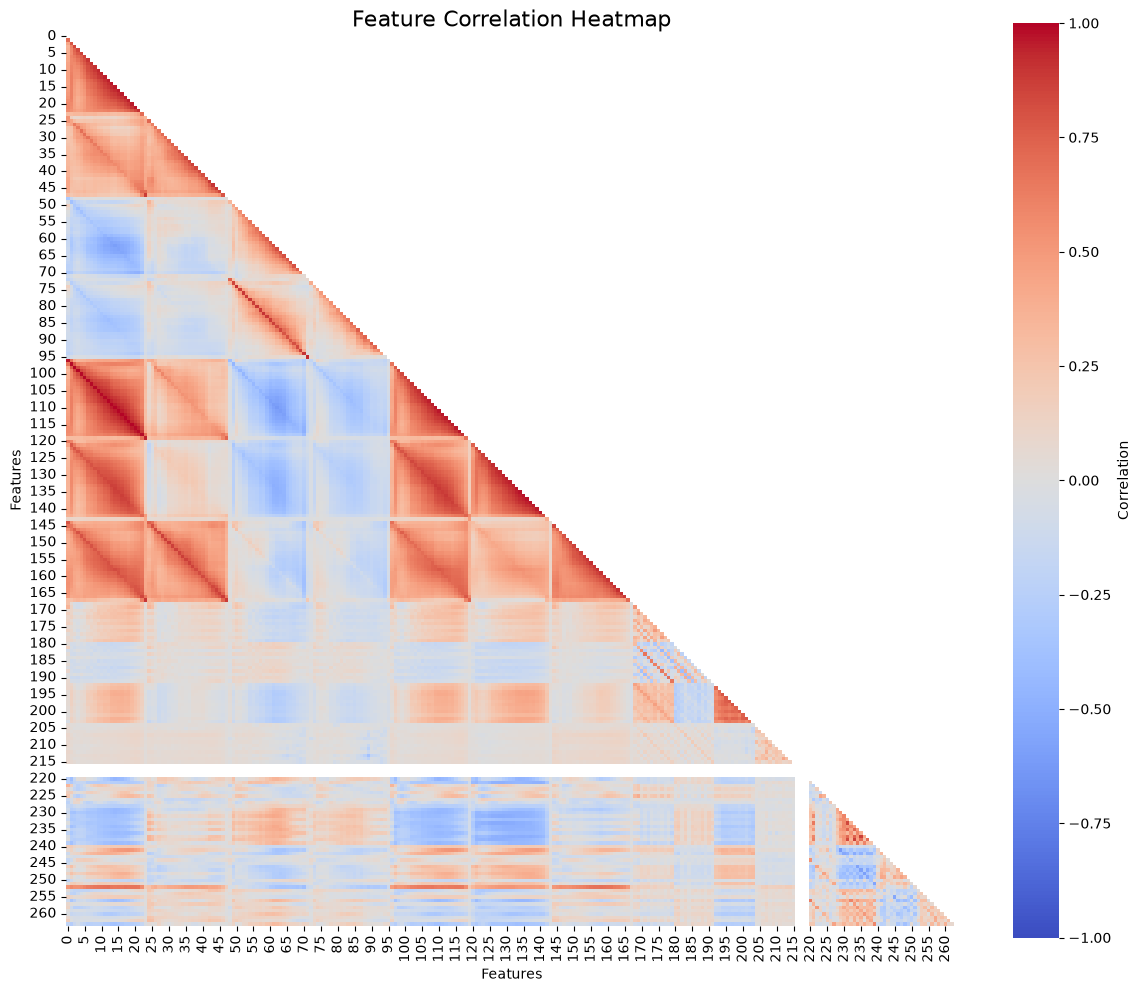

In [13]:
# Calculate correlation matrix
matrix = db_train.corr()

# Mask the upper triangle
mask = np.triu(np.ones_like(matrix, dtype=bool))

plt.figure(figsize=(12, 10))

sns.heatmap(
    matrix,
    mask=mask,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0,
    cbar_kws={"label": "Correlation"}
)

plt.title("Feature Correlation Heatmap", fontsize=16)
plt.xlabel("Features")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [20]:
feature_stats = pd.DataFrame({
    "Minimum": db_train.min(),
    "Maximum": db_train.max(),
    "Mean": db_train.mean(),
    "Std": db_train.std()
})

feature_stats.head()

,Minimum,Maximum,Mean,Std
0,1.240,9172.4,3097.683714,1309.219331
1,3.565,9062.5,4390.947408,1457.625815
2,73.644,8318.1,3987.672465,1228.185868
3,147.370,9342.2,4004.861996,1242.336635
4,58.027,8275.7,3086.664978,1031.020501


## Identifying Constant (Redundant) Features

As part of the exploratory analysis, the statistical properties of each feature were examined to identify redundant variables. Feature **218** was found to be constant across all training samples, with identical minimum, maximum, and mean values and a standard deviation of zero.

| Statistic | Value |
|-----------|------:|
| Minimum | 1,000,000 |
| Maximum | 1,000,000 |
| Mean | 1,000,000 |
| Standard Deviation | 0 |

### Interpretation

A feature with zero variance contains no discriminative information because its value is identical for every sample. Such constant features do not contribute to classification performance and may unnecessarily increase the dimensionality of the dataset. Therefore, this feature will be removed during the preprocessing stage before training the machine learning models.

In [25]:
feature_stats.iloc[218]

Minimum    1000000.0
Maximum    1000000.0
Mean       1000000.0
Std              0.0
Name: 218, dtype: float64

## Identifying Constant (Redundant) Features

In addition to the correlation analysis, the dataset was examined for **constant features** by identifying variables with only one unique value across all training samples. Constant features have zero variance and therefore contain no discriminative information for classification.

The analysis identified **four constant features**:

| Feature | Standard Deviation |
|---------|-------------------:|
| 216 | 0.0 |
| 217 | 0.0 |
| 218 | 0.0 |
| 219 | 0.0 |

### Interpretation

Features **216–219** are constant for every music sample and therefore provide no useful information to distinguish between genres. These redundant features unnecessarily increase the dimensionality of the dataset and will be removed during the preprocessing stage before training the machine learning models.

In [26]:
constant_features = db_train.columns[db_train.nunique() == 1]

print(f"Number of constant features: {len(constant_features)}")
print("Constant features:", list(constant_features))

Number of constant features: 4
Constant features: ['216', '217', '218', '219']


In [28]:
# Threshold for high correlation
threshold = 0.90

# Absolute correlation matrix
corr_matrix = db_train.corr().abs()

# Keep only the upper triangle
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Extract highly correlated pairs
high_corr = (
    upper.stack()
         .reset_index()
         .rename(columns={
             "level_0": "Feature 1",
             "level_1": "Feature 2",
             0: "Correlation"
         })
         .sort_values("Correlation", ascending=False)
         .reset_index(drop=True)   # Removes the old index
)

high_corr = high_corr[high_corr["Correlation"] >= threshold]
high_corr.head(20)

,Feature 1,Feature 2,Correlation
0,14,110,0.995399
1,16,112,0.995230
2,15,111,0.995085
3,17,113,0.994799
4,13,109,0.994584
5,18,114,0.994274
6,3,99,0.993331
7,12,108,0.992779
8,2,98,0.992715
9,19,115,0.992536


## Identifying Redundant Features

To reduce feature redundancy, the absolute Pearson correlation matrix was examined using a correlation threshold of **|r| ≥ 0.90**. For each highly correlated feature pair, one feature was marked as redundant while the other was retained.

### Results

- **Correlation threshold:** 0.90
- **Highly correlated feature pairs:** Identified from the correlation matrix
- **Redundant features identified:** **67**

### Interpretation

A total of **67 features** were identified as redundant due to their strong correlation with other variables. These features contain largely overlapping information and may contribute to multicollinearity without improving the predictive capability of the model. They will be removed during the preprocessing stage, while the remaining features will be used for model training and evaluation.

In [30]:
# Correlation threshold
threshold = 0.90

# Absolute correlation matrix
corr_matrix = db_train.corr().abs()

# Upper triangle only
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Features to remove
redundant_features = [
    column for column in upper.columns
    if any(upper[column] > threshold)
]

print(f"Number of redundant features: {len(redundant_features)}")
pd.DataFrame({
    "Redundant Feature": redundant_features
})

Number of redundant features: 67


,Redundant Feature
0,8
1,9
2,10
3,11
4,12
...,...
62,159
63,160
64,163
65,164


## Correlation Analysis After Feature Reduction

After identifying **67 highly correlated features** and **4 constant features**, these variables were removed to reduce redundancy within the dataset. The resulting feature set contains **193 informative features**, providing a more compact representation of the original audio descriptors.

### Interpretation

The updated correlation heatmap shows a noticeable reduction in large blocks of strong correlations, indicating that much of the multicollinearity has been eliminated. Although some moderate correlations remain, these relationships are expected because different audio descriptors naturally capture related spectral and temporal characteristics.

This reduced feature set will be used during the preprocessing and model development stages to improve computational efficiency while preserving the informative structure of the dataset.

Original features: 264
Remaining features: 193
Removed features: 71


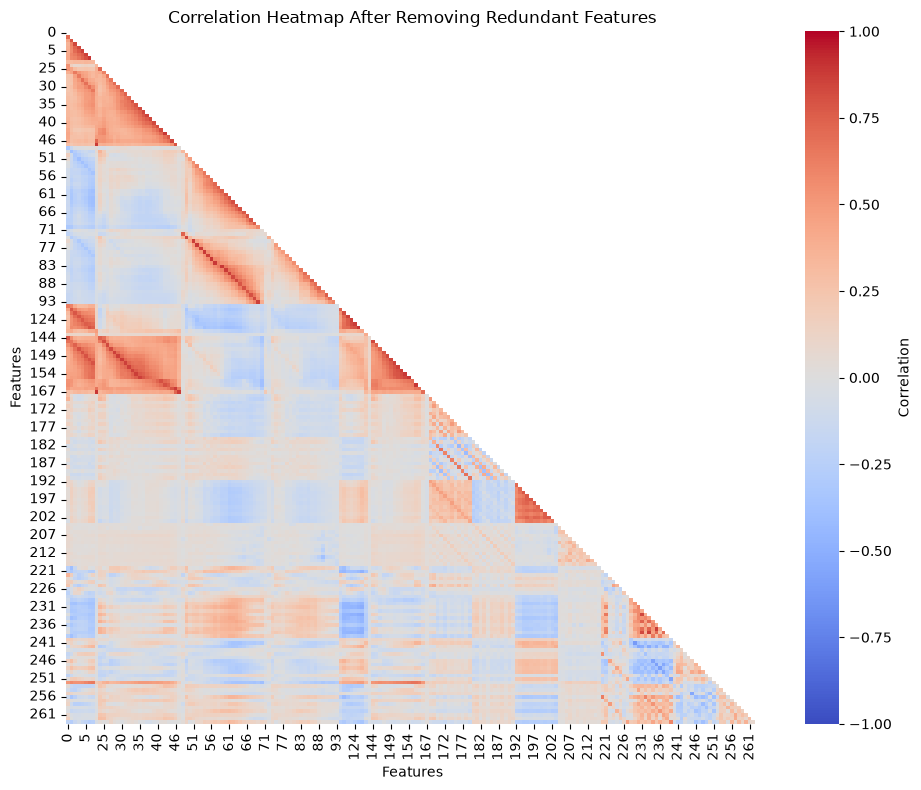

In [31]:
# Remove constant and redundant features
features_to_remove = ['216', '217', '218', '219'] + redundant_features

db_train_reduced = db_train.drop(columns=features_to_remove)

print(f"Original features: {db_train.shape[1]}")
print(f"Remaining features: {db_train_reduced.shape[1]}")
print(f"Removed features: {len(features_to_remove)}")

# Correlation matrix of the reduced dataset
corr_reduced = db_train_reduced.corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr_reduced, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_reduced,
    mask=mask,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Heatmap After Removing Redundant Features")
plt.xlabel("Features")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## Preparing Features and Target Labels

The feature matrix and target labels are converted from Pandas DataFrames into NumPy arrays. This format is required by most machine learning algorithms and preprocessing methods provided by Scikit-learn, including Principal Component Analysis (PCA).

- **X** contains the extracted audio features for each music sample.
- **y** contains the corresponding genre label for each sample.

In [14]:
X=db_train.to_numpy()
y=db_train_lable['label'].to_numpy()

## 2D Principal Component Analysis (PCA)

The correlation analysis showed that many audio features are highly correlated, indicating the presence of redundant information in the 261-dimensional feature space. To explore the overall structure of the dataset, Principal Component Analysis (PCA) is applied after standardizing the features.

PCA transforms the original features into a new set of orthogonal variables called **principal components**, where each component captures the maximum possible variance while remaining uncorrelated with the others. For visualization purposes, the data are projected onto the first two principal components.

### Explained Variance

- **PC1:** 26.72%
- **PC2:** 10.20%
- **Total explained variance:** **36.92%**

### Interpretation

The 2D PCA projection provides a simplified visualization of the high-dimensional audio feature space. While some genres exhibit partial clustering, a substantial overlap is observed among most classes. This indicates that the extracted features contain discriminative information, but the separation between music genres is not fully captured by the first two linear principal components.

In this notebook, PCA is used exclusively as an **exploratory visualization technique**. The original feature set is retained for subsequent preprocessing and model training.

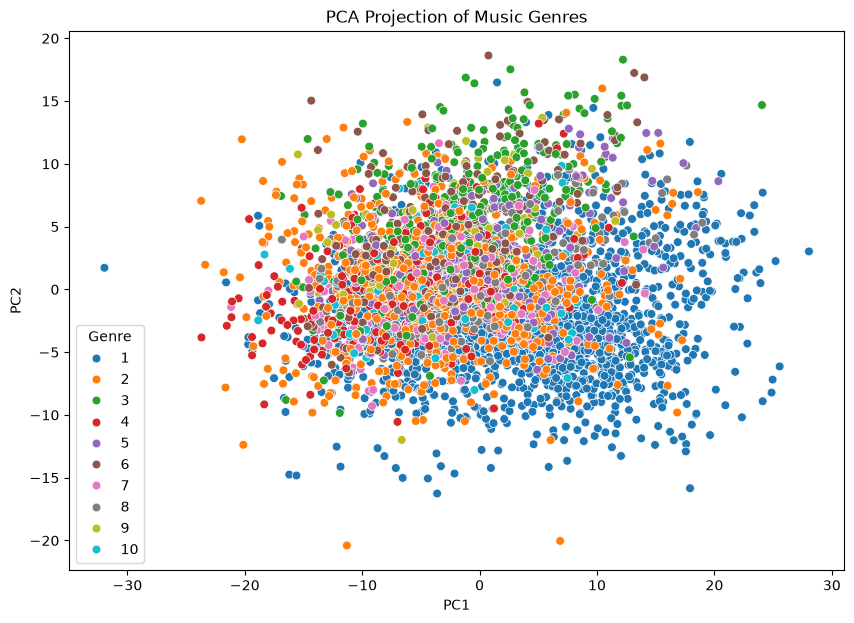

Explained variance: [0.26716879 0.10200809]
Total variance: 0.3691768723204195


In [15]:

# X = features, y = genre labels
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Genre": y
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Genre",
    palette="tab10",
    s=40
)
plt.title("PCA Projection of Music Genres")
plt.show()

print("Explained variance:", pca.explained_variance_ratio_)
print("Total variance:", pca.explained_variance_ratio_.sum())

## 3D Principal Component Analysis (PCA)

To further investigate the structure of the dataset, the standardized audio features are projected onto the first three principal components. Compared to the 2D projection, the additional third component preserves more of the original variance and provides a more informative visualization of the high-dimensional feature space.

Unlike the static 2D plot, the 3D visualization can be rotated and explored interactively, making it easier to observe the spatial distribution of different music genres.

### Explained Variance

| Principal Component | Explained Variance |
|--------------------|-------------------:|
| PC1 | 26.72% |
| PC2 | 10.20% |
| PC3 | 5.41% |
| **Total** | **42.32%** |

### Interpretation

The first three principal components preserve **42.32%** of the total variance, representing a noticeable improvement over the 2D projection. However, the visualization still shows substantial overlap between most genre classes, indicating that the decision boundaries are distributed across higher dimensions rather than being clearly separable in three-dimensional space.

This observation suggests that dimensionality reduction is valuable for understanding the data structure, but the complete feature set is likely to contain additional information that is important for accurate music genre classification.

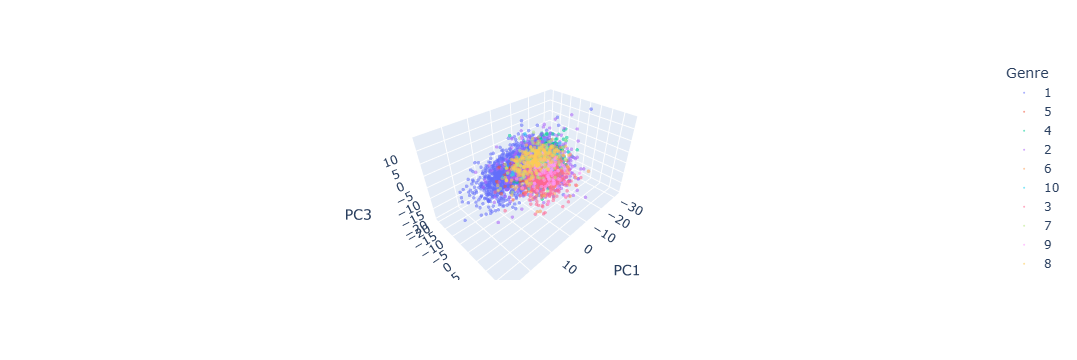

In [16]:
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "PC3": X_pca[:,2],
    "Genre": y.astype(str)
})

fig = px.scatter_3d(
    pca_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Genre",
    opacity=0.55
)

fig.update_traces(marker=dict(size=2))
fig.show()